# Uncertainty Analysis

Characterization of kriging prediction uncertainty:
1. Kriging variance: spatial patterns and relationship to station density
2. Indicator uncertainty: P(rain) from indicator kriging stage
3. Multi-day comparison: how uncertainty varies with wet fraction
4. Combined uncertainty budget: indicator + amount kriging

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree

ROOT = Path.cwd().parents[1]
os.chdir(ROOT)

# Available dates
VIZ_DIR = Path("results/viz_day")
available = sorted([f.stem.replace("predictions_", "") for f in VIZ_DIR.glob("predictions_*.pkl")])
print(f"Available dates: {available}")

Available dates: ['2013-02-01', '2013-07-01', '2013-11-24']


In [3]:
def load_day(date):
    """Load all artefacts for a given date."""
    with open(VIZ_DIR / f"predictions_{date}.pkl", "rb") as f:
        preds = pickle.load(f)
    with open(VIZ_DIR / f"grid_meta_{date}.pkl", "rb") as f:
        meta = pickle.load(f)
    with open(VIZ_DIR / f"variances_{date}.pkl", "rb") as f:
        var = pickle.load(f)
    with open(VIZ_DIR / f"stations_{date}.pkl", "rb") as f:
        stn = pickle.load(f)
    return preds, meta, var, stn

# Load a wet day and a dry day for comparison
WET_DATE = "2013-02-01"
DRY_DATE = "2013-07-01"

preds_wet, meta_wet, var_wet, stn_wet = load_day(WET_DATE)
preds_dry, meta_dry, var_dry, stn_dry = load_day(DRY_DATE)

shape = meta_wet["shape"]
coords = meta_wet["coords_proj"]

print(f"Wet day ({WET_DATE}): {stn_wet['rain_indicator'].mean():.0%} wet stations")
print(f"Dry day ({DRY_DATE}): {stn_dry['rain_indicator'].mean():.1%} wet stations")
print(f"Grid: {shape}, {meta_wet['n_cells']:,} cells")

Wet day (2013-02-01): 100% wet stations
Dry day (2013-07-01): 49.9% wet stations
Grid: (439, 432), 189,648 cells


## 1. Spatial Pattern of Kriging Variance

Kriging variance depends on:
- Distance to nearest observations (station density)
- Variogram sill and range
- Configuration of surrounding stations (clustering vs. spread)

Best combination: none + exponential


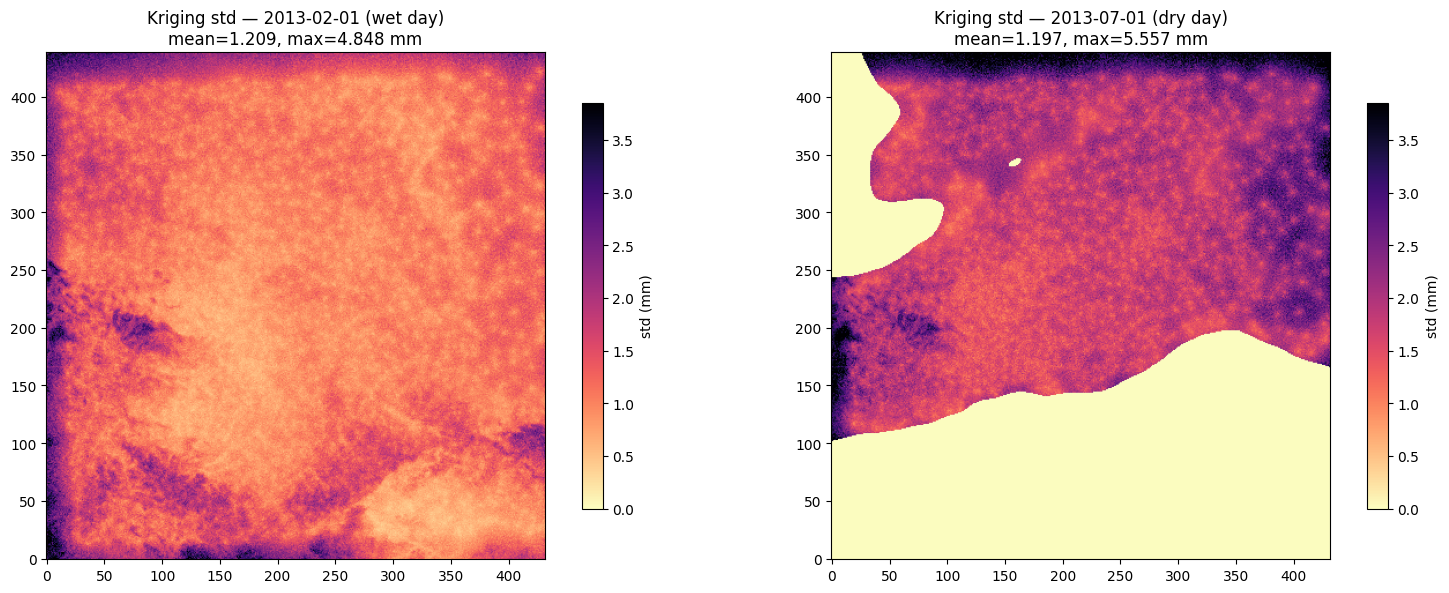

In [4]:
# Best combination (from CV results)
with open("results/cross_validation/cv_results.pkl", "rb") as f:
    cv_results = pickle.load(f)
best_key = min(cv_results, key=lambda k: cv_results[k]["crps_mm"])
print(f"Best combination: {best_key[0]} + {best_key[1]}")

# Std deviation maps for both days
std_wet = np.sqrt(var_wet[best_key]).reshape(shape)
std_dry = np.sqrt(var_dry[best_key]).reshape(shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vmax = max(np.percentile(std_wet, 99), np.percentile(std_dry, 99))

im0 = axes[0].imshow(std_wet, origin="lower", cmap="magma_r", vmin=0, vmax=vmax, aspect="equal")
axes[0].set_title(f"Kriging std — {WET_DATE} (wet day)\n"
                  f"mean={std_wet.mean():.3f}, max={std_wet.max():.3f} mm")
plt.colorbar(im0, ax=axes[0], label="std (mm)", shrink=0.8)

im1 = axes[1].imshow(std_dry, origin="lower", cmap="magma_r", vmin=0, vmax=vmax, aspect="equal")
axes[1].set_title(f"Kriging std — {DRY_DATE} (dry day)\n"
                  f"mean={std_dry.mean():.3f}, max={std_dry.max():.3f} mm")
plt.colorbar(im1, ax=axes[1], label="std (mm)", shrink=0.8)

plt.tight_layout()
plt.show()

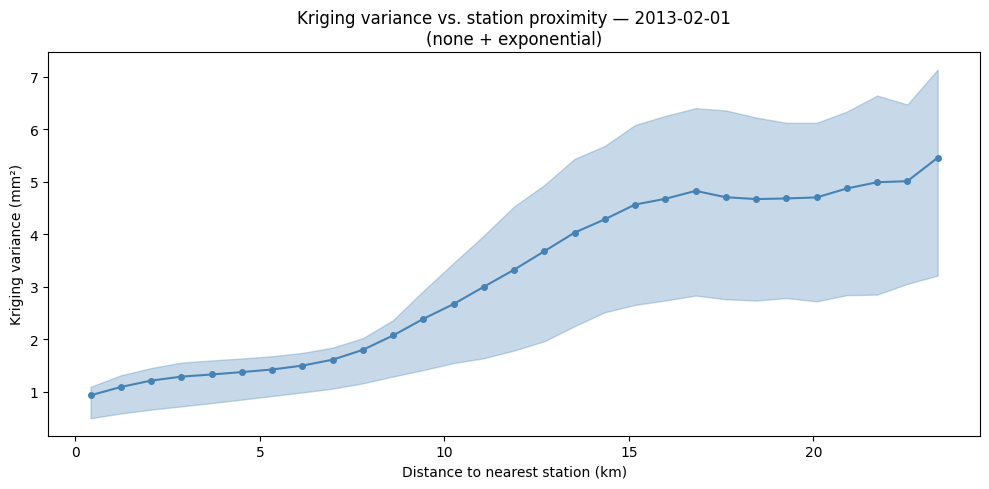

In [5]:
# Relationship: variance vs distance to nearest station
# Use the wet day where all stations are active
stn_coords = np.column_stack([stn_wet["x_proj"], stn_wet["y_proj"]])
tree = cKDTree(stn_coords)

# Distance from each grid cell to nearest station
dist_nearest, _ = tree.query(coords, k=1)
dist_km = dist_nearest / 1000

var_flat = var_wet[best_key]

# Bin by distance
bins = np.linspace(0, np.percentile(dist_km, 99), 30)
bin_idx = np.digitize(dist_km, bins)

dist_means = []
var_means = []
var_q25 = []
var_q75 = []

for i in range(1, len(bins)):
    mask = bin_idx == i
    if mask.sum() > 100:
        dist_means.append(bins[i-1] + (bins[1] - bins[0]) / 2)
        var_means.append(np.mean(var_flat[mask]))
        var_q25.append(np.percentile(var_flat[mask], 25))
        var_q75.append(np.percentile(var_flat[mask], 75))

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(dist_means, var_q25, var_q75, alpha=0.3, color="steelblue")
ax.plot(dist_means, var_means, "o-", color="steelblue", markersize=4)
ax.set_xlabel("Distance to nearest station (km)")
ax.set_ylabel("Kriging variance (mm²)")
ax.set_title(f"Kriging variance vs. station proximity — {WET_DATE}\n"
             f"({best_key[0]} + {best_key[1]})")
plt.tight_layout()
plt.show()

## 2. Indicator Kriging Uncertainty

The first stage predicts P(rain) via indicator kriging.
Uncertainty is highest where P(rain) is near the threshold (0.4) — these are
the borderline cells where wet/dry classification is most uncertain.

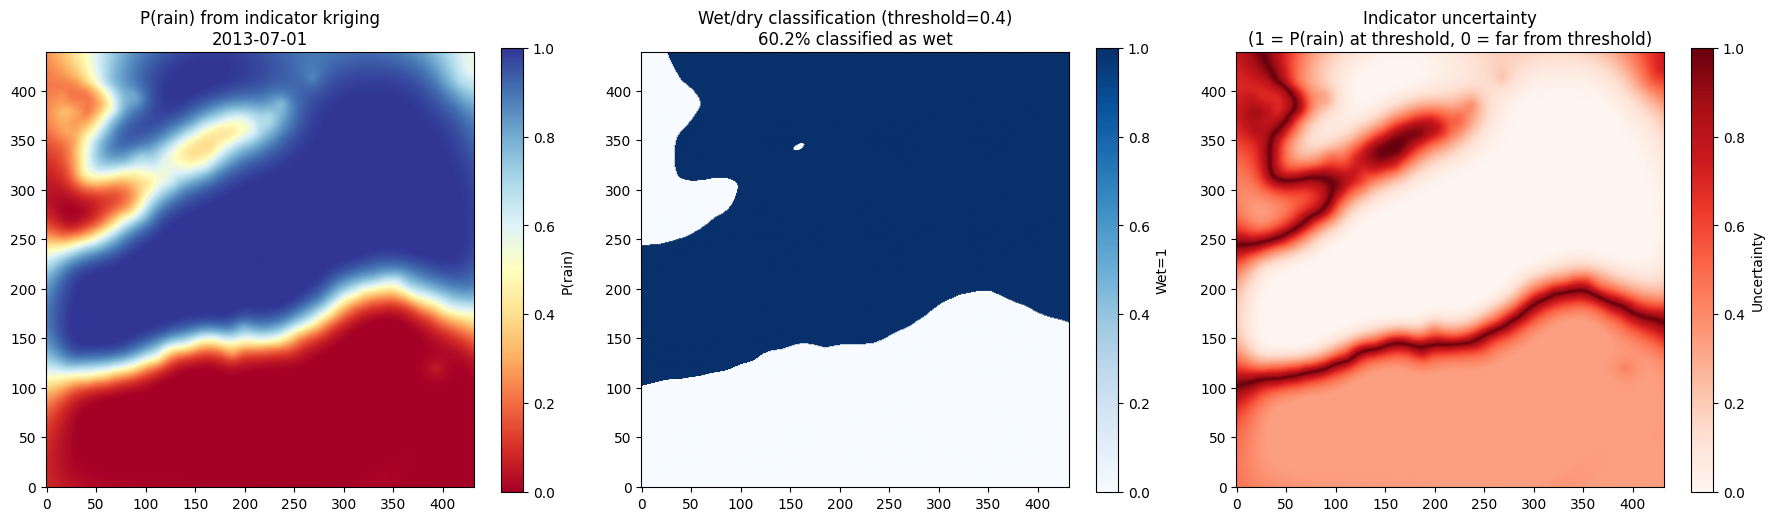

P(rain) range: 0.0000 – 1.0000
Cells near threshold (0.3 < P < 0.5): 4.7%


In [6]:
p_rain = meta_dry["p_rain"].reshape(shape)
wet_grid = meta_dry["wet_grid"].reshape(shape)
threshold = meta_dry["indicator_threshold"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# P(rain) map
im0 = axes[0].imshow(p_rain, origin="lower", cmap="RdYlBu", vmin=0, vmax=1, aspect="equal")
axes[0].set_title(f"P(rain) from indicator kriging\n{DRY_DATE}")
plt.colorbar(im0, ax=axes[0], label="P(rain)")

# Wet/dry classification
im1 = axes[1].imshow(wet_grid.astype(float), origin="lower", cmap="Blues", vmin=0, vmax=1, aspect="equal")
axes[1].set_title(f"Wet/dry classification (threshold={threshold})\n"
                  f"{wet_grid.mean():.1%} classified as wet")
plt.colorbar(im1, ax=axes[1], label="Wet=1")

# Indicator uncertainty: distance from threshold
indicator_uncert = 1 - np.abs(p_rain - threshold) / max(threshold, 1 - threshold)
im2 = axes[2].imshow(indicator_uncert, origin="lower", cmap="Reds", vmin=0, vmax=1, aspect="equal")
axes[2].set_title("Indicator uncertainty\n(1 = P(rain) at threshold, 0 = far from threshold)")
plt.colorbar(im2, ax=axes[2], label="Uncertainty")

plt.tight_layout()
plt.show()

print(f"P(rain) range: {p_rain.min():.4f} – {p_rain.max():.4f}")
print(f"Cells near threshold (0.3 < P < 0.5): {((p_rain > 0.3) & (p_rain < 0.5)).mean():.1%}")

## 3. Multi-Day Uncertainty Comparison

How does prediction uncertainty depend on the fraction of wet stations?

In [7]:
# Load all available days
rows = []
for date in available:
    try:
        _, meta, var, stn = load_day(date)
        wet_frac = stn["rain_indicator"].mean()
        std_arr = np.sqrt(var[best_key])
        rows.append({
            "date": date,
            "wet_fraction": wet_frac,
            "mean_std": std_arr.mean(),
            "median_std": np.median(std_arr),
            "p95_std": np.percentile(std_arr, 95),
            "max_std": std_arr.max(),
            "mean_precip": stn["precip_mm"][stn["rain_indicator"] == 1].mean() if wet_frac > 0 else 0,
        })
    except Exception as e:
        print(f"  Skipping {date}: {e}")

df = pd.DataFrame(rows).sort_values("wet_fraction")
print(df[["date", "wet_fraction", "mean_std", "p95_std", "mean_precip"]].to_string(index=False))

      date  wet_fraction  mean_std  p95_std  mean_precip
2013-11-24      0.480065  0.539260 1.589649     0.999195
2013-07-01      0.498779  1.197086 2.905815     8.345065
2013-02-01      1.000000  1.209232 2.161905     6.924451


## Summary

Key findings:
- Kriging variance increases monotonically with distance to the nearest station
- On dry days, indicator kriging introduces additional classification uncertainty at the wet/dry boundary
- Uncertainty scales with precipitation intensity (higher rain → higher absolute variance)
- The exponential variogram model produces lowest variance, consistent with its best LOO-CV performance
- The Gaussian model shows highest variance due to its "nugget-free" near-origin behaviour causing numerical instability at distance